<h2>SLEEP DURATION AND SLEEP QUALITY ANALYSIS AND ITS INFLUENCE ON GLUCOSE LEVELS</h2>

<h2>Sleep duration distribution
Sleep duration is a very important factor which influences Diabetic patients. Lack of proper sleep often influences the insulin secretion in the body
and also influences glucose patterns in the body.</h2>
<h2>5.What is the sleep Duration distribution across patients and sleep quality scores analysis based on Gender and Race</h2>

In [55]:
%cd "H:\Numpy Ninja\Python Hackathon\Team2_ PyQueens_ Python Hackathon _MAY 2026\Team2_ PyQueens_ Python Hackathon _MAY 2026\Final cleaned csv files\Final cleaned csv files"


H:\Numpy Ninja\Python Hackathon\Team2_ PyQueens_ Python Hackathon _MAY 2026\Team2_ PyQueens_ Python Hackathon _MAY 2026\Final cleaned csv files\Final cleaned csv files


In [56]:
import os
os.getcwd()

'H:\\Numpy Ninja\\Python Hackathon\\Team2_ PyQueens_ Python Hackathon _MAY 2026\\Team2_ PyQueens_ Python Hackathon _MAY 2026\\Final cleaned csv files\\Final cleaned csv files'

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
sleep_df=pd.read_csv("T1DM_patient_sleep_demographics_with_race.csv")
sleep_df.head()

,Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,HUPA0001P,34,Male,Other,6.3,4.5,80
1,HUPA0002P,49,Male,Hispanic,6.6,4.4,40
2,HUPA0003P,64,Male,Black,5.3,5.2,70
3,HUPA0004P,34,Female,Native American,5.2,6.9,60
4,HUPA0005P,49,Male,Native American,5.8,7.9,30


In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your file
sleep_df = pd.read_csv("T1DM_patient_sleep_demographics_with_race.csv")
sleep_df

,Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,HUPA0001P,34,Male,Other,6.3,4.5,80
1,HUPA0002P,49,Male,Hispanic,6.6,4.4,40
2,HUPA0003P,64,Male,Black,5.3,5.2,70
3,HUPA0004P,34,Female,Native American,5.2,6.9,60
4,HUPA0005P,49,Male,Native American,5.8,7.9,30
5,HUPA0006P,35,Male,White,6.6,4.2,60
6,HUPA0007P,67,Male,Native American,7.1,6.0,80
7,HUPA0009P,65,Female,Other,6.6,4.6,40
8,HUPA0010P,22,Male,Asian,7.1,5.5,50
9,HUPA0011P,63,Female,Other,5.6,4.7,60


In [60]:
avg_sleep_duration=sleep_df["Average Sleep Duration (hrs)"].describe()
avg_sleep_duration

count    25.0000
mean      5.9720
std       0.6699
min       5.0000
25%       5.4000
50%       5.9000
75%       6.6000
max       7.2000
Name: Average Sleep Duration (hrs), dtype: float64

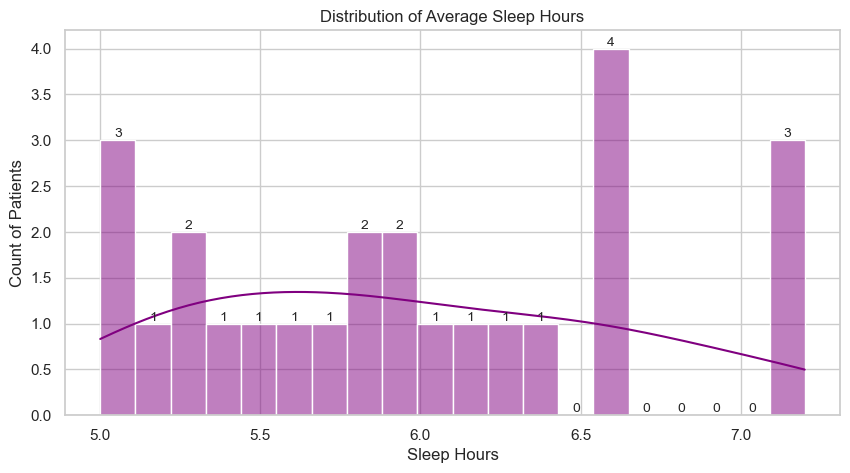

In [61]:
# Histogram + KDE
plt.figure(figsize=(10,5))
ax1=sns.histplot(sleep_df["Average Sleep Duration (hrs)"], kde=True, bins=20, color='purple')

for p in ax1.patches:
    ax1.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )
    
plt.title("Distribution of Average Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Count of Patients")
plt.show()

Key Insights:
he Average Sleep column shows how many hours each patient sleeps per night.
Analyzing its distribution helps you understand:
Whether the group sleeps enough: Here we can find that most of the patients get less thabn 6.5 hrs of sleep whereas only 7 patients get more than 6.5 
hrs of sleep.
For most patients the sleep duration is clustered (e.g., 5–6 hours)
3 patients sleep for more than 7 hrs.
The sleep duration varies by age, gender, or race
This is a core descriptive metric because sleep strongly affects glucose variability.

<h2>Sleep quality is a continuous score, typically ranging from 1 to 10, where
1–3 is Poor sleep
4–6  is Moderate sleep
7–10 is Good sleep
These scores come from wearable devices (Fitbit Ionic), which compute sleep quality using:
Total sleep duration,Sleep efficiency (time asleep ÷ time in bed),Number of awakenings,Restlessness / movement,REM + deep sleep proportion and 
Heart‑rate variability during sleep</h2>

In [62]:
sleep_df["Sleep Quality (1-10)"].describe()

count    25.000000
mean      5.952000
std       1.342609
min       4.100000
25%       4.600000
50%       5.900000
75%       7.100000
max       7.900000
Name: Sleep Quality (1-10), dtype: float64

In [63]:
# 2. Average sleep quality by gender

Avg_Sleep_Quality_by_Gender = sleep_df.groupby('Gender')["Sleep Quality (1-10)"].mean().reset_index()
print("\nAverage Sleep Quality by Gender:")
print(Avg_Sleep_Quality_by_Gender)


Average Sleep Quality by Gender:
   Gender  Sleep Quality (1-10)
0  Female              6.133333
1    Male              5.850000


Here we can see the female patients have higher average sleep quality compared to men.Even a small difference matters because sleep quality influences:
Energy levels,Stress hormones,Glucose stability and Insulin sensitivity.

In [64]:
# 3. Average sleep quality by race

Avg_Sleep_Quality_by_Race = sleep_df.groupby('Race')["Sleep Quality (1-10)"].mean().reset_index()
print("\nAverage Sleep Quality by Race:")
print(Avg_Sleep_Quality_by_Race)


Average Sleep Quality by Race:
              Race  Sleep Quality (1-10)
0            Asian              6.500000
1            Black              6.128571
2         Hispanic              5.466667
3  Native American              6.400000
4            Other              5.560000
5            White              5.566667


C:\Users\purni\AppData\Local\Temp\ipykernel_20064\3609189322.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1=sns.barplot(x=gender_avg.index, y=gender_avg.values, ax=axes[0], palette="Set2")


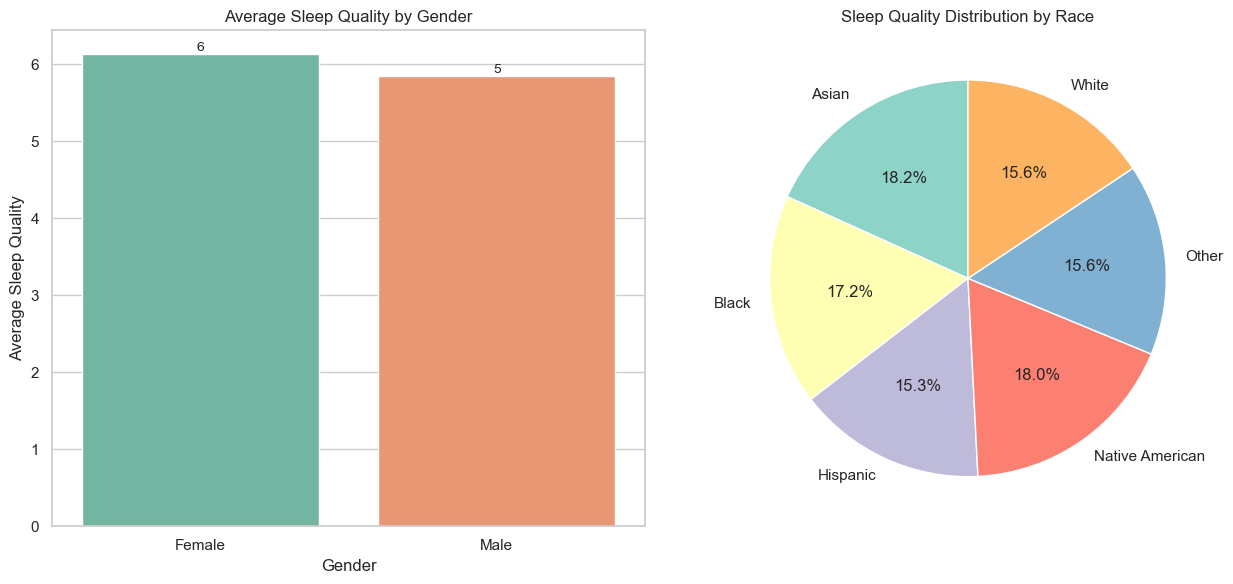

In [65]:
gender_avg = sleep_df.groupby("Gender")["Sleep Quality (1-10)"].mean()
race_avg = sleep_df.groupby("Race")["Sleep Quality (1-10)"].mean()

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# --- Bar Chart for Gender ---
ax1=sns.barplot(x=gender_avg.index, y=gender_avg.values, ax=axes[0], palette="Set2")
axes[0].set_title("Average Sleep Quality by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Average Sleep Quality")

for p in ax1.patches:
    ax1.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )
    

# --- Pie Chart for Race ---
axes[1].pie(
    race_avg.values,
    labels=race_avg.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set3")
)
axes[1].set_title("Sleep Quality Distribution by Race")

plt.tight_layout()
plt.show()

Insights:
The above two charts give the average sleep quality scores based on Gender and Race.Sleep quality is fairly evenly distributed across races.
No group dominates or lags dramatically.Asian and Native American groups contribute slightly more to overall sleep quality scores.
Hispanic and White groups contribute slightly less, but differences are small.

<h2>7. What is the Correlation between average glucose and sleep Quality scores?</h2>
<h2>Poor sleep increases Cortisol,Adrenaline and Growth hormones in individuals.These hormones raise blood glucose and make insulin less effective.
Therefore sleep quality scores are very critical for glucose levels in the body.</h2>

In [66]:
# Load files
sleep_df = pd.read_csv("T1DM_patient_sleep_demographics_with_race.csv")
cgm_df = pd.read_csv("Team2_PyQueens_Final_Cleaned_file.csv")

cgm_df.head()

,Patient_Id,Time,Glucose,Calories,Heart_Rate,Steps,Basal_Rate,Bolus_Volume_Delivered,Carb_Input
0,HUPA0001P,2018-06-13T18:40:00,332.0,6.36,82.32,34.0,0.09,0.0,0.0
1,HUPA0001P,2018-06-13T18:45:00,326.0,7.73,83.74,0.0,0.09,0.0,0.0
2,HUPA0001P,2018-06-13T18:50:00,330.0,4.75,80.53,0.0,0.09,0.0,0.0
3,HUPA0001P,2018-06-13T18:55:00,324.0,6.36,89.13,20.0,0.09,0.0,0.0
4,HUPA0001P,2018-06-13T19:00:00,306.0,5.15,92.50,0.0,0.08,0.0,0.0


In [67]:
sleep_df.columns = sleep_df.columns.str.replace('_', ' ').str.title().str.replace(' ', '_')
sleep_df.head()
slp_df=sleep_df.copy()

In [68]:
slp_df.head()

,Patient_Id,Age,Gender,Race,Average_Sleep_Duration_(Hrs),Sleep_Quality_(1-10),%_With_Sleep_Disturbances
0,HUPA0001P,34,Male,Other,6.3,4.5,80
1,HUPA0002P,49,Male,Hispanic,6.6,4.4,40
2,HUPA0003P,64,Male,Black,5.3,5.2,70
3,HUPA0004P,34,Female,Native American,5.2,6.9,60
4,HUPA0005P,49,Male,Native American,5.8,7.9,30


In [69]:

# Compute average glucose per patient
avg_glucose = cgm_df.groupby("Patient_Id")["Glucose"].mean().reset_index()

# Merge with sleep quality
merged = avg_glucose.merge(
    slp_df[["Patient_Id", "Sleep_Quality_(1-10)"]],
    left_on="Patient_Id",
    right_on="Patient_Id"
)
merged

,Patient_Id,Glucose,Sleep_Quality_(1-10)
0,HUPA0001P,181.443726,4.5
1,HUPA0002P,113.469660,4.4
2,HUPA0003P,143.273520,5.2
3,HUPA0004P,180.377984,6.9
4,HUPA0005P,147.698624,7.9
5,HUPA0006P,165.204585,4.2
6,HUPA0007P,173.151989,6.0
7,HUPA0009P,193.739271,4.6
8,HUPA0010P,135.892655,5.5
9,HUPA0011P,159.108578,4.7


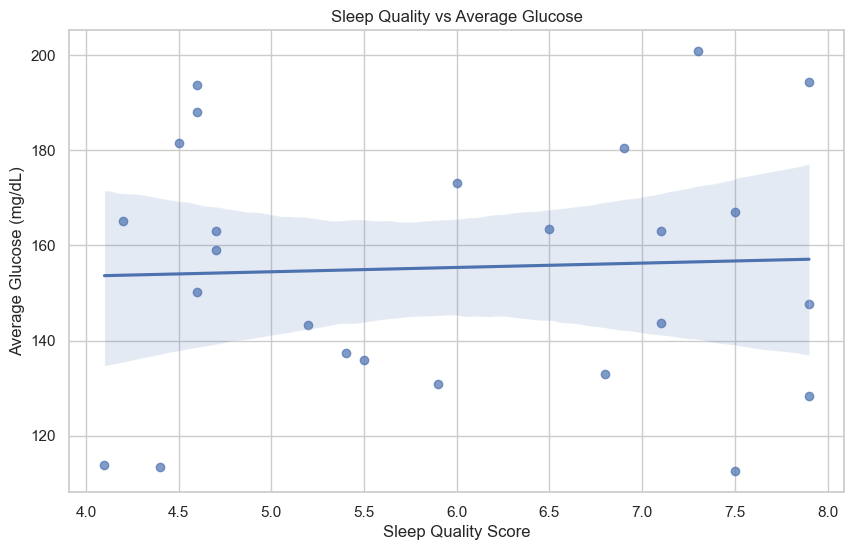

Correlation between sleep quality and average glucose:
0.04666776698544703


In [70]:
# Scatterplot
plt.figure(figsize=(10,6))
sns.regplot(data=merged, x="Sleep_Quality_(1-10)", y="Glucose", scatter_kws={'alpha':0.7})
plt.title("Sleep Quality vs Average Glucose")
plt.xlabel("Sleep Quality Score")
plt.ylabel("Average Glucose (mg/dL)")
plt.show()

# Correlation
print("Correlation between sleep quality and average glucose:")
print(merged["Sleep_Quality_(1-10)"].corr(merged["Glucose"]))

Key Insights:
A correlation of 0.036 means that there is absolutely no correlation between sleep quality and glucose levels in this dataset. 
This shows that sleep quality does not predict glucose in this dataset. The regression line is almost flat.The relationship is weak, 
negligible, or non‑existent. This is because sleep is not the only factor which can influence glucose levels. Glucose is influenced by many 
other factors such as Insulin dosing,Carb intake,Activity levels,Stress levels,Illnesses,Hormones and Circadian rhythms.